**Examen Final - Clasificación de Mortalidad Hospitalaria**

Diego Andrés Burbano A.


## **1. Importar librerias necesarias para el modelo**

In [1]:
#Instalación de ydata-profiling para reporte de perfilamiento de data
!pip install ydata-profiling

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 399.3/399.3 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.1 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.2
    Uninstalling scipy-1.16.2:
      Successfully uninstalled scipy-1.16.2


In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, make_scorer, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from ydata_profiling import ProfileReport
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler
#from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.base import clone
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score, roc_auc_score)

import os
from google.colab import drive



## **2. Carga de datos y evaluación del set de datos proporcionado**

In [3]:
# En esta celda se esta montando el drive  que tiene almacenado los datos en la ruta MyDrive/datos
drive.mount('/content/drive', force_remount=True)

# una vez se montó el drive, se cambia la ruta de archivo de 'content' de Colab por la ruta de Google Drive ('/MyDrive/datos/')
os.chdir('/content/drive/MyDrive/datos/')

Mounted at /content/drive


Se realiza una revisión preliminar del set de datos:

In [4]:
data = pd.read_csv('./data_train.csv', sep=',')
data.head()

,Unnamed: 0,age,sex,dzgroup,dzclass,num.co,scoma,avtisst,race,sps,...,dnr,dnrday,meanbp,hrt,resp,temp,crea,sod,adlsc,hospdead
0,0,62.84998,male,Lung Cancer,Cancer,0,0.0,7.000000,other,33.898438,...,no dnr,5.0,97.0,69.0,22.0,36.00000,1.199951,141.0,7.0,0
1,1,60.33899,female,Cirrhosis,COPD/CHF/Cirrhosis,2,44.0,29.000000,white,52.695312,...,NaN,NaN,43.0,112.0,34.0,34.59375,5.500000,132.0,1.0,1
2,2,52.74698,female,Cirrhosis,COPD/CHF/Cirrhosis,2,0.0,13.000000,white,20.500000,...,no dnr,17.0,70.0,88.0,28.0,37.39844,2.000000,134.0,0.0,0
3,3,42.38498,female,Lung Cancer,Cancer,2,0.0,7.000000,white,20.097656,...,no dnr,3.0,75.0,88.0,32.0,35.00000,0.799927,139.0,0.0,0
4,4,79.88495,female,ARF/MOSF w/Sepsis,ARF/MOSF,1,26.0,18.666656,white,23.500000,...,no dnr,16.0,59.0,112.0,20.0,37.89844,0.799927,143.0,2.0,0


In [5]:
#Cantidad y dimensionalidad de los datos
data.shape

(9105, 27)

In [6]:
#Perfilamiento inicial de los datos
data.describe()

,Unnamed: 0,age,num.co,scoma,avtisst,sps,aps,surv2m,surv6m,hday,...,dementia,dnrday,meanbp,hrt,resp,temp,crea,sod,adlsc,hospdead
count,9105.000000,9105.000000,9105.000000,9104.000000,9023.000000,9104.000000,9104.000000,9104.000000,9104.000000,9105.000000,...,9105.000000,9075.000000,9104.000000,9104.000000,9104.000000,9104.000000,9038.000000,9104.000000,9105.000000,9105.000000
mean,4552.000000,62.650823,1.868644,12.058546,22.610928,25.525872,37.597979,0.635870,0.520096,4.400000,...,0.032510,14.582590,84.546408,97.156711,23.330294,37.103341,1.770961,137.568541,1.888272,0.259198
std,2628.531434,15.593710,1.344409,24.636694,13.233248,9.899377,19.903852,0.248175,0.253343,9.126811,...,0.177359,19.944216,27.687692,31.559292,9.573801,1.251796,1.686041,6.029326,2.003763,0.438219
min,0.000000,18.041990,0.000000,0.000000,1.000000,0.199982,0.000000,0.000000,0.000000,1.000000,...,0.000000,-88.000000,0.000000,0.000000,0.000000,31.699220,0.099991,110.000000,0.000000,0.000000
25%,2276.000000,52.797000,1.000000,0.000000,12.000000,19.000000,23.000000,0.507690,0.342957,1.000000,...,0.000000,4.000000,63.000000,72.000000,18.000000,36.195310,0.899902,134.000000,0.000000,0.000000
50%,4552.000000,64.856990,2.000000,0.000000,19.500000,23.898438,34.000000,0.715942,0.574951,1.000000,...,0.000000,9.000000,77.000000,100.000000,24.000000,36.695310,1.199951,137.000000,1.000000,0.000000
75%,6828.000000,73.998960,3.000000,9.000000,31.666656,30.199219,49.000000,0.825928,0.725952,3.000000,...,0.000000,17.000000,107.000000,120.000000,28.000000,38.195310,1.899902,141.000000,3.000000,1.000000
max,9104.000000,101.847960,9.000000,100.000000,83.000000,99.187500,143.000000,0.969971,0.947998,148.000000,...,1.000000,285.000000,195.000000,300.000000,90.000000,41.695310,21.500000,181.000000,7.073242,1.000000


In [ ]:
profile = ProfileReport(data, title="Reporte de Perfilamiento", explorative=True)

In [ ]:
profile.to_notebook_iframe()

Output hidden; open in https://colab.research.google.com to view.

**Características del set de datos**



*   El set de datos presenta un desbalanceo favoreciendo a la clase 0 (sobrevivientes) frente a la clase 1 (paciente fallecido) la cual tiene un 26% de representatividad. Considerando el tipo de aplicación para la cual se hace el presente notebook, esto representa un problema ya que existe un sesgo natural hacia la clase negativa, la cual no es el objeto de la predicción.
*   List item



**Análisis de balance de datos en el set:**

Como se indicó en la descripción de las características del set de datos, existe un desbalanceo favoreciendo a la clase que no es el objeto de la predicción. Considerando que este modelo pretende predecir la mortalidad en centros médicos, un sesgo hacia la clase "superviviente" debe ser evitado, ya que limitaría el valor clínico del modelo.

Por esta razón, se toma la decisión de balancear el set de datos utilizando técnicas de oversampling. Esta técnica se prefiere porque no altera los registros existentes, sino que replica o sintetiza ejemplos de la clase minoritaria, preservando así la integridad del dataset original.

Se descarta el uso de imputación de datos en este contexto, ya que, tratándose de aplicaciones médicas, la creación de datos ficticios para variables críticas podría falsear la realidad clínica. Esto representaría un alto riesgo ético y metodológico, aun si mejorara artificialmente las métricas de desempeño.

Adicionalmente, para evaluar el modelo de forma justa en presencia de este desbalance, se utilizarán métricas robustas como F1-score, recall y AUC, que permiten valorar el desempeño en la predicción de la clase minoritaria con mayor precisión que la simple métrica de accuracy.

**Análisis de datos faltantes**

In [7]:
#Revisión de datos faltantes totales
print(f"Total de datos nulos en el dataset: {data.isna().sum().sum()}")

#Revisión de datos faltantes por clase
faltantes_col = data.isna().sum()
faltantes_pct = (faltantes_col / len(data)) * 100
faltantes_df = pd.DataFrame({
    'Faltantes': faltantes_col,
    'Porcentaje': faltantes_pct
}).sort_values(by="Porcentaje", ascending=False)

print(faltantes_df)

Total de datos nulos en el dataset: 261
            Faltantes  Porcentaje
avtisst            82    0.900604
crea               67    0.735859
race               42    0.461285
dnr                30    0.329489
dnrday             30    0.329489
aps                 1    0.010983
hrt                 1    0.010983
surv2m              1    0.010983
sps                 1    0.010983
resp                1    0.010983
scoma               1    0.010983
temp                1    0.010983
sod                 1    0.010983
meanbp              1    0.010983
surv6m              1    0.010983
age                 0    0.000000
Unnamed: 0          0    0.000000
num.co              0    0.000000
sex                 0    0.000000
dzclass             0    0.000000
dzgroup             0    0.000000
hday                0    0.000000
diabetes            0    0.000000
dementia            0    0.000000
ca                  0    0.000000
adlsc               0    0.000000
hospdead            0    0.000000


Encontramos un total de 261 datos faltantes

In [8]:
# Filtramos solo las filas que tienen al menos un NaN
filas_con_nulos = data[data.isna().any(axis=1)]

# Mostramos cuántas son
print("Número de filas con nulos:", len(filas_con_nulos))

# Sumamos la columna hospdead en ese subconjunto
suma_hospdead = filas_con_nulos["hospdead"].sum()

print("Suma de hospdead en esas filas:", suma_hospdead)


Número de filas con nulos: 217
Suma de hospdead en esas filas: 49


Los 261 datos faltantes se concentran en un total de 217 filas. Del total de 217 filas con datos nulos, 49 pertenecen a la clase menos dominante (hospdead = 1).

Se toma la decisión de eliminar las 217 filas por las siguientes razones:

*   Desde el punto de vista técnico, eliminar 217 filas representa un bajo volumen considerando el volumen total del dataset. Representatividad inferior al 3%.
*   Los datos a eliminar no se concentran en una única variable y el volumen de los mismos es inferior al 1% del volumen total de la misma según se ve en la revisión de datos por clase.
*   Si bien perder 49 datos positivos de la variable 'hospdead' puede afectar el recall del modelo, pero se prefiere esto para tener un dataset limpio.
*   La alternativa de imputar datos no se considera ya que por el tipo de aplicación, en este caso detección de morbilidad, la invención de datos para variables críticas implica manipular la integridad del set de datos, lo cual éticamente es un problema.

Procederemos con la eliminación en la siguiente sección del notebook.

**Análisis de datos repetidos:**

In [9]:
#Identificación de datos repetidos
print(f'Datos duplicados: {data.duplicated().sum()}')

Datos duplicados: 0


No existen datos duplicados o repetidos.

### **2.1 Pre - alistamiento del set de datos**

De acuerdo con las conclusiones presentadas en el análisis del dataset, procederemos preparar nuestro set de datos realizando las siguientes acciones sobre el mismo:
1. Eliminación de la variable 'unnamed'
2. Eliminación de los registros que presenten datos nulos (217 en total)

In [48]:
# Obtenemos una copia del set de datos
data_clean = data.copy()
data_clean.shape

(9105, 27)

In [49]:
# Eliminación de la variable 'unnamed'
data_clean.drop('Unnamed: 0', axis=1, inplace=True)
data_clean.head()

,age,sex,dzgroup,dzclass,num.co,scoma,avtisst,race,sps,aps,...,dnr,dnrday,meanbp,hrt,resp,temp,crea,sod,adlsc,hospdead
0,62.84998,male,Lung Cancer,Cancer,0,0.0,7.000000,other,33.898438,20.0,...,no dnr,5.0,97.0,69.0,22.0,36.00000,1.199951,141.0,7.0,0
1,60.33899,female,Cirrhosis,COPD/CHF/Cirrhosis,2,44.0,29.000000,white,52.695312,74.0,...,NaN,NaN,43.0,112.0,34.0,34.59375,5.500000,132.0,1.0,1
2,52.74698,female,Cirrhosis,COPD/CHF/Cirrhosis,2,0.0,13.000000,white,20.500000,45.0,...,no dnr,17.0,70.0,88.0,28.0,37.39844,2.000000,134.0,0.0,0
3,42.38498,female,Lung Cancer,Cancer,2,0.0,7.000000,white,20.097656,19.0,...,no dnr,3.0,75.0,88.0,32.0,35.00000,0.799927,139.0,0.0,0
4,79.88495,female,ARF/MOSF w/Sepsis,ARF/MOSF,1,26.0,18.666656,white,23.500000,30.0,...,no dnr,16.0,59.0,112.0,20.0,37.89844,0.799927,143.0,2.0,0


In [50]:
# Eliminación de registros con datos nulos
data_clean.dropna(inplace=True)
data_clean.shape

(8888, 26)

Se eliminan en total 217 registros o filas del set de datos

##**3. Preparación de los sets de entrenamiento**

Con el fin de evitar el data leakage dividimos nuestro set de datos limpio (data_clean) en entrenamiento (train) y prueba (test).

In [51]:
# Dividir los datos (X) y variable objetivo (y)
X = data_clean.drop('hospdead', axis=1)
y = data_clean['hospdead']

# Dividir los datos en conjuntos de entrenamiento y prueba
#Set (80% entrenamiento / 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=42)


## **4. Desarrollo de pipeline de transformación de data**

In [52]:
# Parámetros de preprocesamiento de los datos

# Variables categóricas por tipo de codificación
ohe_vars = ["dzgroup", "dzclass", "race"]
ordinal_vars = ["ca"]
dnr_vars = ["dnr"]
sex_vars = ["sex"]

# Identificar columnas numéricas (todas las demás que no son categóricas)
numeric_vars = [col for col in X_train.columns if col not in ohe_vars + ordinal_vars + dnr_vars + sex_vars]

# Definir transformadores
preprocessor = ColumnTransformer(
    transformers=[
        ("ohe", OneHotEncoder(drop="first", sparse_output=False), ohe_vars),
        ("ordinal", OrdinalEncoder(), ordinal_vars),
        ("dnr", OrdinalEncoder(), dnr_vars),
        ("sex", OrdinalEncoder(categories=[["male", "female"]]), sex_vars),
        ("num", RobustScaler(), numeric_vars)
    ],
    remainder="drop"
)

In [53]:
# Preparacion de pipeline de transformacion

pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("undersampler", RandomUnderSampler(random_state=42)),
    ("classifier", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

In [54]:
# Diccionario de métricas
scoring_metrics = {
    'Accuracy': 'accuracy',
    'F1_Weighted': 'f1_weighted',
    'Precision_Weighted': 'precision_weighted',
    'Recall_Weighted': 'recall_weighted',
    'ROC_AUC': 'roc_auc'
}

In [55]:
# Definición de espacios de hiperparámetros para los modelos seleccionados:

param_grid = [
    {   # Regresión Logística
        "classifier": [LogisticRegression(max_iter=2000, solver="liblinear")],
        "classifier__C": [0.1, 1, 10],
        "classifier__penalty": ["l1", "l2"],
        "classifier__class_weight": [None, "balanced"]
    },
    {   # Random Forest
        "classifier": [RandomForestClassifier(random_state=42)],
        "classifier__n_estimators": [100, 200],
        "classifier__max_depth": [None, 10, 20],
        "classifier__min_samples_split": [2, 5],
        "classifier__class_weight": [None, "balanced"]
    },
    {   # XGBoost
        "classifier": [XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)],
        "classifier__n_estimators": [100, 200],
        "classifier__max_depth": [3, 5, 7],
        "classifier__learning_rate": [0.01, 0.1],
        "classifier__subsample": [0.8, 1.0],
        "classifier__colsample_bytree": [0.8, 1.0]
    }
]

grid = GridSearchCV(
    pipeline,
    param_grid,
    scoring=scoring_metrics,
    refit='F1_Weighted',
    cv=5,
    n_jobs=-1,
    verbose=2
)

In [56]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 84 candidates, totalling 420 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [19:25:15] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('ohe',
                                                                         OneHotEncoder(drop='first',
                                                                                       sparse_output=False),
                                                                         ['dzgroup',
                                                                          'dzclass',
                                                                          'race']),
                                                                        ('ordinal',
                                                                         OrdinalEncoder(),
                                                                         ['ca']),
                                                                        ('dnr',
                                                                         OrdinalEncoder(),
                                                                         ['dnr']),
                                                                        ('sex',
                                                                         OrdinalEncoder(categories=[['male',
                                                                                                     'female']]),
                                                                         ['sex']),
                                                                        ('num',
                                                                         RobustScaler(),
                                                                         ['age',
                                                                          'num.co',
                                                                          's...
                          'classifier__colsample_bytree': [0.8, 1.0],
                          'classifier__learning_rate': [0.01, 0.1],
                          'classifier__max_depth': [3, 5, 7],
                          'classifier__n_estimators': [100, 200],
                          'classifier__subsample': [0.8, 1.0]}],
             refit='F1_Weighted',
             scoring={'Accuracy': 'accuracy', 'F1_Weighted': 'f1_weighted',
                      'Precision_Weighted': 'precision_weighted',
                      'ROC_AUC': 'roc_auc',
                      'Recall_Weighted': 'recall_weighted'},
             verbose=2)

In [64]:
best_model_name = grid.best_estimator_.named_steps['classifier'].__class__.__name__
best_params_clean = {k: v for k, v in grid.best_params_.items() if k != "classifier"}

print("Mejor modelo:", best_model_name)
print("Mejor f1_weighted:", grid.best_score_)

best_model_name = grid.best_estimator_.named_steps['classifier'].__class__.__name__
params_df = pd.DataFrame(best_params_clean.items(), columns=["Hiperparámetro", "Valor"])
print(params_df.to_string(index=False))

Mejor modelo: XGBClassifier
Mejor f1_weighted: 0.8910650728590405
              Hiperparámetro  Valor
classifier__colsample_bytree   0.80
   classifier__learning_rate   0.01
       classifier__max_depth   3.00
    classifier__n_estimators 200.00
       classifier__subsample   1.00


Resultados en TRAIN:
              precision    recall  f1-score   support

           0       0.95      0.90      0.93      5258
           1       0.75      0.87      0.81      1852

    accuracy                           0.89      7110
   macro avg       0.85      0.88      0.87      7110
weighted avg       0.90      0.89      0.89      7110


Resultados en TEST:
              precision    recall  f1-score   support

           0       0.93      0.90      0.91      1319
           1       0.73      0.81      0.77       459

    accuracy                           0.88      1778
   macro avg       0.83      0.86      0.84      1778
weighted avg       0.88      0.88      0.88      1778



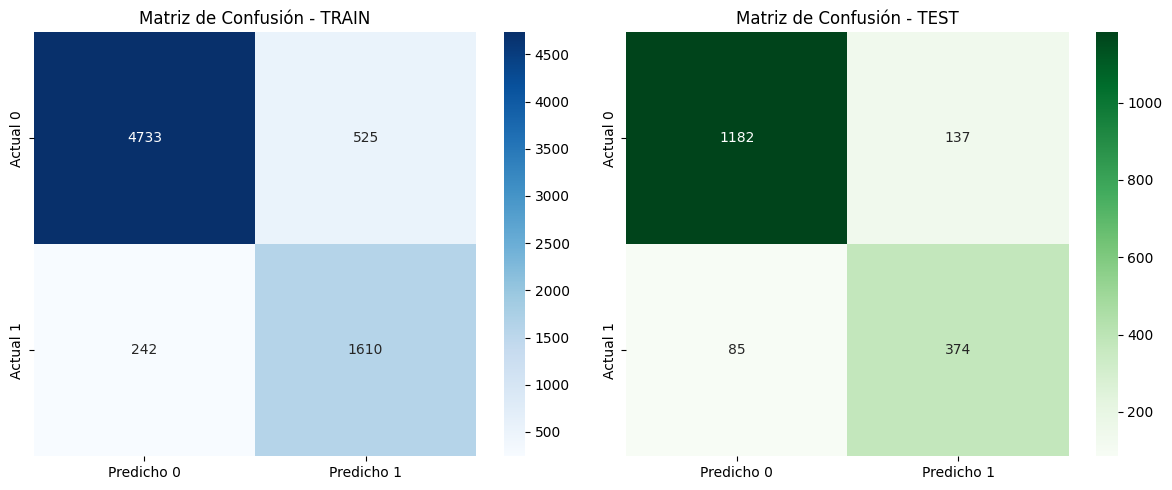

In [81]:
best_model = grid.best_estimator_

# Predicciones
y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

# Reportes
print("Resultados en TRAIN:")
print(classification_report(y_train, y_pred_train))

print("\nResultados en TEST:")
print(classification_report(y_test, y_pred_test))

# Matriz de confusión para TRAIN
cm_train = confusion_matrix(y_train, y_pred_train)
cm_train_df = pd.DataFrame(
    cm_train,
    index=['Actual 0', 'Actual 1'],
    columns=['Predicho 0', 'Predicho 1']
)

# Matriz de confusión para TEST
cm_test = confusion_matrix(y_test, y_pred_test)
cm_test_df = pd.DataFrame(
    cm_test,
    index=['Actual 0', 'Actual 1'],
    columns=['Predicho 0', 'Predicho 1']
)

# Dibujar ambas en la misma fila
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_train_df, annot=True, cmap='Blues', fmt='g', ax=axes[0])
axes[0].set_title("Matriz de Confusión - TRAIN")

sns.heatmap(cm_test_df, annot=True, cmap='Greens', fmt='g', ax=axes[1])
axes[1].set_title("Matriz de Confusión - TEST")

plt.tight_layout()
plt.show()


In [82]:
# Resultados completos de todas las combinaciones
results = pd.DataFrame(grid.cv_results_)

# Extraer el mejor modelo por tipo de clasificador
best_models = {}
for model_name in ["LogisticRegression", "RandomForestClassifier", "XGBClassifier"]:
    # Filtrar filas que correspondan a ese modelo
    subset = results[results['param_classifier'].astype(str).str.contains(model_name)]
    # Ordenar por F1_Weighted (mean test score)
    best_row = subset.loc[subset['mean_test_F1_Weighted'].idxmax()]
    best_models[model_name] = {
        "mean_test_Accuracy": best_row['mean_test_Accuracy'],
        "mean_test_F1_Weighted": best_row['mean_test_F1_Weighted'],
        "mean_test_Precision_Weighted": best_row['mean_test_Precision_Weighted'],
        "mean_test_Recall_Weighted": best_row['mean_test_Recall_Weighted'],
        "mean_test_ROC_AUC": best_row['mean_test_ROC_AUC'],
        "mean_test_params": best_row['params']
    }

# Pasar a DataFrame para mejor visualización
best_models_df = pd.DataFrame(best_models).T
rename_map = {
    "mean_test_Accuracy": "Accuracy",
    "mean_test_F1_Weighted": "F1_Weighted",
    "mean_test_Precision_Weighted": "Precision_Weighted",
    "mean_test_Recall_Weighted": "Recall_Weighted",
    "mean_test_ROC_AUC": "ROC_AUC",
    "mean_test_params": "Mejores_Hiperparametros"
}
best_models_df = best_models_df.rename(columns=rename_map)

# Presentación de hiperparámetros
def format_params(params_dict):
    # Excluir el objeto del modelo completo
    clean_params = {k: v for k, v in params_dict.items() if k != "classifier"}
    # Convertir a string más legible tipo "param = valor"
    return ", ".join([f"{k}={v}" for k, v in clean_params.items()])

best_models_df["Mejores_Hiperparametros"] = best_models_df["Mejores_Hiperparametros"].apply(format_params)
best_models_df = best_models_df.round(3)

from IPython.display import display
display(
    best_models_df.style.set_caption("MEJORES MODELOS POR ALGORITMO")
    .background_gradient(cmap="Blues", subset=["F1_Weighted"])
    .set_properties(subset=["Mejores_Hiperparametros"], **{'text-align': 'left', 'width': '400px'})
)


,Accuracy,F1_Weighted,Precision_Weighted,Recall_Weighted,ROC_AUC,Mejores_Hiperparametros
LogisticRegression,0.879044,0.882367,0.891149,0.879044,0.943709,"classifier__C=0.1, classifier__class_weight=None, classifier__penalty=l1"
RandomForestClassifier,0.881435,0.884902,0.894726,0.881435,0.943951,"classifier__class_weight=None, classifier__max_depth=10, classifier__min_samples_split=2, classifier__n_estimators=100"
XGBClassifier,0.888467,0.891065,0.897428,0.888467,0.944952,"classifier__colsample_bytree=0.8, classifier__learning_rate=0.01, classifier__max_depth=3, classifier__n_estimators=200, classifier__subsample=1.0"


In [76]:
# Crear un diccionario para guardar métricas de TEST
best_models_test = {}

# Iterar sobre los mejores modelos identificados en la tabla de entrenamiento
for model_name, row in best_models.items():
    # Extraer parámetros del mejor modelo
    params = row["mean_test_params"]

    # Crear una nueva instancia del pipeline con esos parámetros
    model = clone(grid.best_estimator_)
    model.set_params(**params)

    # Entrenar en el conjunto completo de TRAIN
    model.fit(X_train, y_train)

    # Predecir sobre TEST
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Calcular métricas
    best_models_test[model_name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1_Weighted": f1_score(y_test, y_pred, average="weighted"),
        "Precision_Weighted": precision_score(y_test, y_pred, average="weighted"),
        "Recall_Weighted": recall_score(y_test, y_pred, average="weighted"),
        "ROC_AUC": roc_auc_score(y_test, y_proba),
        "Best_Params": format_params(params)
    }

# Convertir a DataFrame
best_models_test_df = pd.DataFrame(best_models_test).T
best_models_test_df = best_models_test_df.round(3)

# Mostrar tabla con estilo
display(best_models_test_df.style.set_caption("MEJORES MODELOS POR ALGORITMO (TEST)")
                           .background_gradient(cmap="Greens", subset=["F1_Weighted"]))


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [20:11:16] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,Accuracy,F1_Weighted,Precision_Weighted,Recall_Weighted,ROC_AUC,Best_Params
LogisticRegression,0.862767,0.866401,0.874651,0.862767,0.934900,"classifier__C=0.1, classifier__class_weight=None, classifier__penalty=l1"
RandomForestClassifier,0.873453,0.876514,0.883391,0.873453,0.939178,"classifier__class_weight=None, classifier__max_depth=10, classifier__min_samples_split=2, classifier__n_estimators=100"
XGBClassifier,0.875141,0.877232,0.881020,0.875141,0.937377,"classifier__colsample_bytree=0.8, classifier__learning_rate=0.01, classifier__max_depth=3, classifier__n_estimators=200, classifier__subsample=1.0"
